# PD logistic regression and held-out validation

This notebook models the probability that an account is good. Probability of default (PD) is calculated explicitly as `1 - P(good)`. It consumes the engineered train/test matrices from notebooks 00–03.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

processed = Path('../data/processed')

## Load the model matrices and targets

The files below are produced by the preceding notebooks. They are intentionally loaded rather than rebuilt here.

In [2]:
with open(processed / 'model_inputs_train.pkl', 'rb') as f:
    inputs_train_all = pickle.load(f)
with open(processed / 'model_inputs_test.pkl', 'rb') as f:
    inputs_test_all = pickle.load(f)
with open(processed / 'targets_train.pkl', 'rb') as f:
    targets_train = pickle.load(f)
with open(processed / 'targets_test.pkl', 'rb') as f:
    targets_test = pickle.load(f)

targets_train = pd.Series(targets_train).astype(int)
targets_test = pd.Series(targets_test).astype(int)

## Original candidate inventory and reference levels

This is the full candidate inventory selected in the original model notebook. One level per dummy family is omitted as its reference so coefficients remain identifiable.

In [3]:
candidate_features = '''grade:A grade:B grade:C grade:D grade:E grade:F grade:G home_ownership:RENT_OTHER_NONE_ANY home_ownership:OWN home_ownership:MORTGAGE addr_state:ND_NE_IA_NV_FL_HI_AL addr_state:NM_VA addr_state:NY addr_state:OK_TN_MO_LA_MD_NC addr_state:CA addr_state:UT_KY_AZ_NJ addr_state:AR_MI_PA_OH_MN addr_state:RI_MA_DE_SD_IN addr_state:GA_WA_OR addr_state:WI_MT addr_state:TX addr_state:IL_CT addr_state:KS_SC_CO_VT_AK_MS addr_state:WV_NH_WY_DC_ME_ID verification_status:Not_Verified verification_status:Source_Verified verification_status:Verified purpose:educ__sm_b__wedd__ren_en__mov__house purpose:credit_card purpose:debt_consolidation purpose:oth__med__vacation purpose:major_purch__car__home_impr initial_list_status:f initial_list_status:w term:36 term:60 emp_length:0 emp_length:1 emp_length:2-4 emp_length:5-6 emp_length:7-9 emp_length:10 mths_since_issue_d:<38 mths_since_issue_d:38-39 mths_since_issue_d:40-41 mths_since_issue_d:42-48 mths_since_issue_d:49-52 mths_since_issue_d:53-64 mths_since_issue_d:65-84 mths_since_issue_d:>84 int_rate:<9.548 int_rate:9.548-12.025 int_rate:12.025-15.74 int_rate:15.74-20.281 int_rate:>20.281 mths_since_earliest_cr_line:<140 mths_since_earliest_cr_line:141-164 mths_since_earliest_cr_line:165-247 mths_since_earliest_cr_line:248-270 mths_since_earliest_cr_line:271-352 mths_since_earliest_cr_line:>352 delinq_2yrs:0 delinq_2yrs:1-3 delinq_2yrs:>=4 inq_last_6mths:0 inq_last_6mths:1-2 inq_last_6mths:3-6 inq_last_6mths:>6 open_acc:0 open_acc:1-3 open_acc:4-12 open_acc:13-17 open_acc:18-22 open_acc:23-25 open_acc:26-30 open_acc:>=31 pub_rec:0-2 pub_rec:3-4 pub_rec:>=5 total_acc:<=27 total_acc:28-51 total_acc:>=52 acc_now_delinq:0 acc_now_delinq:>=1 total_rev_hi_lim:<=5K total_rev_hi_lim:5K-10K total_rev_hi_lim:10K-20K total_rev_hi_lim:20K-30K total_rev_hi_lim:30K-40K total_rev_hi_lim:40K-55K total_rev_hi_lim:55K-95K total_rev_hi_lim:>95K annual_inc:<20K annual_inc:20K-30K annual_inc:30K-40K annual_inc:40K-50K annual_inc:50K-60K annual_inc:60K-70K annual_inc:70K-80K annual_inc:80K-90K annual_inc:90K-100K annual_inc:100K-120K annual_inc:120K-140K annual_inc:>140K dti:<=1.4 dti:1.4-3.5 dti:3.5-7.7 dti:7.7-10.5 dti:10.5-16.1 dti:16.1-20.3 dti:20.3-21.7 dti:21.7-22.4 dti:22.4-35 dti:>35 mths_since_last_delinq:Missing mths_since_last_delinq:0-3 mths_since_last_delinq:4-30 mths_since_last_delinq:31-56 mths_since_last_delinq:>=57 mths_since_last_record:Missing mths_since_last_record:0-2 mths_since_last_record:3-20 mths_since_last_record:21-31 mths_since_last_record:32-80 mths_since_last_record:81-86 mths_since_last_record:>86'''.split()
feature_labels = {'verification_status:Not_Verified': 'verification_status:Not Verified', 'verification_status:Source_Verified': 'verification_status:Source Verified', 'mths_since_earliest_cr_line:<140': 'mths_since_earliest_cr_line:Missing_or_<140', 'mths_since_earliest_cr_line:141-164': 'mths_since_earliest_cr_line:140-164', 'annual_inc:<20K': 'annual_inc:<=20K'}
candidate_features = [feature_labels.get(name, name) for name in candidate_features]
assert all(name.startswith('verification_status:') for name in candidate_features if name.startswith('verification'))
reference_categories_initial = ['grade:G', 'home_ownership:RENT_OTHER_NONE_ANY', 'addr_state:ND_NE_IA_NV_FL_HI_AL', 'verification_status:Verified', 'purpose:educ__sm_b__wedd__ren_en__mov__house', 'initial_list_status:f', 'term:60', 'emp_length:0', 'mths_since_issue_d:>84', 'int_rate:>20.281', 'mths_since_earliest_cr_line:<140', 'delinq_2yrs:>=4', 'inq_last_6mths:>6', 'open_acc:0', 'pub_rec:0-2', 'total_acc:<=27', 'acc_now_delinq:0', 'total_rev_hi_lim:<=5K', 'annual_inc:<20K', 'dti:>35', 'mths_since_last_delinq:0-3', 'mths_since_last_record:0-2']
reference_categories_initial = [feature_labels.get(name, name) for name in reference_categories_initial]
missing = sorted(set(candidate_features) - set(inputs_train_all.columns))
if missing:
    raise KeyError(f'Candidate columns missing from model checkpoint: {missing}')
X_initial = inputs_train_all[candidate_features].drop(columns=reference_categories_initial)
X_initial.shape

(373028, 104)

### Candidate-family inventory

The inventory spans grade, home ownership, address state, verification, purpose, listing status, term, employment, issue timing, interest rate, credit history, delinquency, inquiry, account-count, revolving-limit, income, debt-to-income, and missingness-aware delinquency/record bands.

In [4]:
pd.Series(candidate_features).str.split(':').str[0].value_counts().sort_index().rename('category_count')

acc_now_delinq                  2
addr_state                     14
annual_inc                     12
delinq_2yrs                     3
dti                            10
emp_length                      6
grade                           7
home_ownership                  3
initial_list_status             2
inq_last_6mths                  4
int_rate                        5
mths_since_earliest_cr_line     6
mths_since_issue_d              8
mths_since_last_delinq          5
mths_since_last_record          7
open_acc                        8
pub_rec                         3
purpose                         5
term                            2
total_acc                       3
total_rev_hi_lim                8
verification_status             3
Name: category_count, dtype: int64

## Initial model and p-values

The inferential model is an unpenalized statsmodels Logit fit with an explicit intercept. The full-rank check makes the coefficient and Wald p-value interface valid for the selected reference-category design.

In [5]:
def fit_logit_with_inference(X, y):
    design = sm.add_constant(X.astype(float), has_constant='add')
    if np.linalg.matrix_rank(design.to_numpy()) != design.shape[1]:
        raise ValueError('Logit design matrix is not full rank')
    result = sm.Logit(pd.Series(y).to_numpy(dtype=float), design).fit(disp=False)
    if not result.mle_retvals.get('converged', False):
        raise RuntimeError('Logit maximum-likelihood fit did not converge')
    if not np.isfinite(result.params).all() or not np.isfinite(result.pvalues).all():
        raise RuntimeError('Logit inference returned non-finite coefficients or p-values')
    summary = pd.DataFrame({'feature': result.params.index, 'coefficient': result.params.to_numpy(), 'p_value': result.pvalues.to_numpy()})
    return result, design, summary

initial_result, X_initial_design, initial_summary = fit_logit_with_inference(X_initial, targets_train)
initial_summary

,feature,coefficient,p_value
0,const,-2.704068,1.023047e-08
1,grade:A,1.112566,5.139717e-34
2,grade:B,0.895047,1.359538e-48
3,grade:C,0.707723,8.193066e-36
4,grade:D,0.525994,1.444854e-22
...,...,...,...
100,mths_since_last_record:3-20,0.395308,1.508012e-03
101,mths_since_last_record:21-31,0.478140,5.823898e-05
102,mths_since_last_record:32-80,0.603784,4.177463e-11
103,mths_since_last_record:81-86,0.263540,1.418012e-02


## Final specification

The original review removed families whose dummy levels were all or almost all non-significant: delinquencies, open accounts, public records, total accounts, and revolving-limit bands. This retains the broader original final specification rather than the later five-feature simplification.

In [6]:
removed_families = ('delinq_2yrs:', 'open_acc:', 'pub_rec:', 'total_acc:', 'total_rev_hi_lim:')
final_candidate_features = [f for f in candidate_features if not f.startswith(removed_families)]
reference_categories = [f for f in reference_categories_initial if f in final_candidate_features]
X_train = inputs_train_all[final_candidate_features].drop(columns=reference_categories)
X_test = inputs_test_all[final_candidate_features].drop(columns=reference_categories)
final_result, X_train_design, model_summary = fit_logit_with_inference(X_train, targets_train)
X_test_design = sm.add_constant(X_test.astype(float), has_constant='add').reindex(columns=X_train_design.columns)
model_summary

,feature,coefficient,p_value
0,const,-1.704798,4.269862e-27
1,grade:A,1.120518,1.484704e-34
2,grade:B,0.898446,4.538099e-49
3,grade:C,0.710640,3.548128e-36
4,grade:D,0.528939,7.559881e-23
...,...,...,...
80,mths_since_last_record:3-20,0.369039,2.668135e-03
81,mths_since_last_record:21-31,0.447171,1.419170e-04
82,mths_since_last_record:32-80,0.565554,3.820910e-10
83,mths_since_last_record:81-86,0.225905,3.411854e-02


### Final coefficient review

This table provides the final intercept, category coefficients, and diagnostic p-values used to document the retained specification.

In [7]:
model_summary.sort_values(['feature']).reset_index(drop=True)

,feature,coefficient,p_value
0,acc_now_delinq:>=1,0.228526,3.159799e-02
1,addr_state:AR_MI_PA_OH_MN,0.155106,5.254973e-12
2,addr_state:CA,0.087351,3.797737e-05
3,addr_state:GA_WA_OR,0.213429,1.239695e-15
4,addr_state:IL_CT,0.288442,5.371970e-23
...,...,...,...
80,purpose:major_purch__car__home_impr,0.266535,2.240664e-17
81,purpose:oth__med__vacation,0.190688,9.335876e-10
82,term:36,0.084713,1.693054e-09
83,verification_status:Not Verified,0.096311,8.132064e-11


## Held-out predictions

`P(good)` is the probability of target class 1. The PD column is its complement; no probability is relabelled implicitly.

In [8]:
p_good = final_result.predict(X_test_design)
validation_predictions = pd.DataFrame({'actual_good': targets_test.to_numpy(), 'p_good': np.asarray(p_good)})
validation_predictions['pd'] = 1 - validation_predictions['p_good']
validation_predictions.head()

,actual_good,p_good,pd
0,1,0.891570,0.108430
1,1,0.973000,0.027000
2,1,0.918090,0.081910
3,1,0.905435,0.094565
4,0,0.887232,0.112768


## Threshold analysis

Accuracy can look favorable in this class-imbalanced target, so it is reported alongside the count and proportion confusion matrices rather than as a stand-alone assessment.

In [9]:
thresholds_to_review = [0.5, 0.7, 0.9]
threshold_results = []
for threshold in thresholds_to_review:
    predicted_good = (validation_predictions['p_good'] >= threshold).astype(int)
    matrix = confusion_matrix(validation_predictions['actual_good'], predicted_good, labels=[0, 1])
    threshold_results.append({'threshold': threshold, 'accuracy': (predicted_good == validation_predictions['actual_good']).mean(), 'confusion_matrix': matrix})
threshold_results

[{'threshold': 0.5,
  'accuracy': np.float64(0.8906355555078975),
  'confusion_matrix': array([[   10, 10184],
         [   15, 83048]])},
 {'threshold': 0.7,
  'accuracy': np.float64(0.8841159376776007),
  'confusion_matrix': array([[  589,  9605],
         [ 1202, 81861]])},
 {'threshold': 0.9,
  'accuracy': np.float64(0.5883633400173713),
  'confusion_matrix': array([[ 7289,  2905],
         [35483, 47580]])}]

In [10]:
threshold = 0.5
validation_predictions['predicted_good'] = (validation_predictions['p_good'] >= threshold).astype(int)
confusion_counts = pd.crosstab(validation_predictions['actual_good'], validation_predictions['predicted_good'], rownames=['actual'], colnames=['predicted'])
confusion_proportions = confusion_counts / len(validation_predictions)
display(confusion_counts)
display(confusion_proportions)
print(f'Accuracy at P(good) >= {threshold:.1f}: {(validation_predictions.actual_good == validation_predictions.predicted_good).mean():.3f}')

predicted,0,1
actual,,
0,10,10184
1,15,83048


predicted,0,1
actual,,
0,0.000107,0.109204
1,0.000161,0.890528


Accuracy at P(good) >= 0.5: 0.891


## ROC, AUC, Gini, and KS

These rank-based measures describe discrimination across thresholds. They complement, rather than replace, the threshold results above.

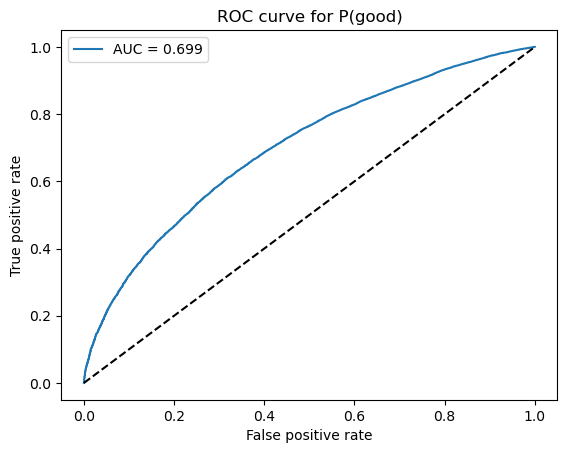

Gini coefficient: 0.399


In [11]:
fpr, tpr, roc_thresholds = roc_curve(validation_predictions['actual_good'], validation_predictions['p_good'])
auc = roc_auc_score(validation_predictions['actual_good'], validation_predictions['p_good'])
gini = 2 * auc - 1
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='black')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve for P(good)')
plt.legend()
plt.show()
print(f'Gini coefficient: {gini:.3f}')

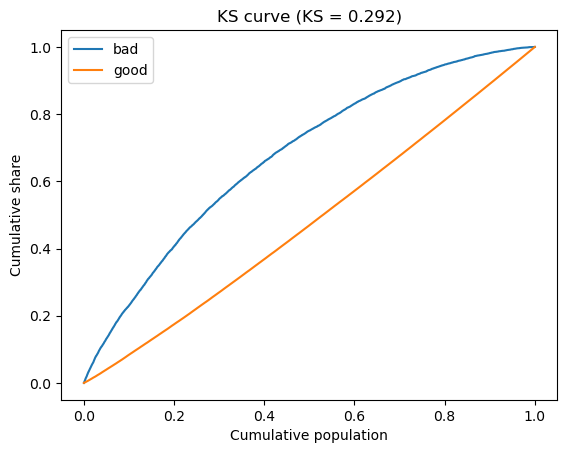

np.float64(0.2916524985747112)

In [12]:
cumulative = validation_predictions.sort_values('p_good').reset_index(drop=True).copy()
cumulative['cumulative_population'] = (cumulative.index + 1) / len(cumulative)
cumulative['cumulative_good'] = cumulative['actual_good'].cumsum() / cumulative['actual_good'].sum()
cumulative['cumulative_bad'] = (1 - cumulative['actual_good']).cumsum() / (1 - cumulative['actual_good']).sum()
ks = (cumulative['cumulative_bad'] - cumulative['cumulative_good']).max()
plt.plot(cumulative['cumulative_population'], cumulative['cumulative_bad'], label='bad')
plt.plot(cumulative['cumulative_population'], cumulative['cumulative_good'], label='good')
plt.xlabel('Cumulative population')
plt.ylabel('Cumulative share')
plt.title(f'KS curve (KS = {ks:.3f})')
plt.legend()
plt.show()
ks

## Save the modeling handoff

The saved model predicts `P(good)`; downstream scorecard work derives PD as `1 - P(good)`.

In [13]:
processed.mkdir(parents=True, exist_ok=True)
with open(processed / 'pd_model.pkl', 'wb') as f:
    pickle.dump(final_result, f)
with open(processed / 'model_feature_names.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)
with open(processed / 'reference_categories.pkl', 'wb') as f:
    pickle.dump(reference_categories, f)
with open(processed / 'validation_predictions.pkl', 'wb') as f:
    pickle.dump(validation_predictions, f)

## Conclusions

On the held-out sample, the final PD model achieves **AUC = 0.699482** (about **0.70**), **Gini = 0.398964** (about **0.399**), and **KS = 0.2916525**. These three measures give a consistent numeric summary of the model's rank-ordering discrimination.

The source interpretation guide classifies ROC AUC bands as 50%–60% bad, 60%–70% poor, 70%–80% fair, 80%–90% good, and 90%–100% excellent. At 0.699482, this result sits directly on the poor/fair boundary when rounded to 0.70. It is therefore best described as **borderline poor-to-fair discrimination**, rather than assigning a stronger label based only on rounding.

The held-out results should be interpreted as a combination of ranking evidence (AUC, Gini, KS) and operational threshold behavior. A high accuracy at a single threshold may mostly reflect the prevalence of good accounts; the ROC and cumulative curves expose the model's discrimination across thresholds. This is an educational historical-data exercise, so the bands provide context rather than an approval standard or evidence that the model is ready for lending decisions.